In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data loading
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv", index_col = "User_ID")
df.columns = df.columns.str.lower().str.replace(" ","_")
df.head()

,age,gender,occupation,device_type,daily_phone_hours,social_media_hours,work_productivity_score,sleep_hours,stress_level,app_usage_count,caffeine_intake_cups,weekend_screen_time_hours
User_ID,,,,,,,,,,,,
U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [3]:
# data understanding
print("Shape: \n",df.shape)
print("Info: \n")
df.info()
print("Description: \n")
df.describe()

Shape: 
 (50000, 12)
Info: 

<class 'pandas.DataFrame'>
Index: 50000 entries, U1 to U50000
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        50000 non-null  int64  
 1   gender                     50000 non-null  str    
 2   occupation                 50000 non-null  str    
 3   device_type                50000 non-null  str    
 4   daily_phone_hours          50000 non-null  float64
 5   social_media_hours         50000 non-null  float64
 6   work_productivity_score    50000 non-null  int64  
 7   sleep_hours                50000 non-null  float64
 8   stress_level               50000 non-null  int64  
 9   app_usage_count            50000 non-null  int64  
 10  caffeine_intake_cups       50000 non-null  int64  
 11  weekend_screen_time_hours  50000 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 6.2 MB
Description: 



,age,daily_phone_hours,social_media_hours,work_productivity_score,sleep_hours,stress_level,app_usage_count,caffeine_intake_cups,weekend_screen_time_hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


In [4]:
# <- data cleaning ->
df.isnull().sum()
#no null values in any column, thus no need for replacinf null values

age                          0
gender                       0
occupation                   0
device_type                  0
daily_phone_hours            0
social_media_hours           0
work_productivity_score      0
sleep_hours                  0
stress_level                 0
app_usage_count              0
caffeine_intake_cups         0
weekend_screen_time_hours    0
dtype: int64

In [58]:
#removing duplicates
df = df.drop_duplicates()

In [48]:
# <- adding columns ->

#phone usage - low, medium, high
df["phone_usage_category"] = pd.cut(
    df["daily_phone_hours"],
    bins = [0,3,6,9,24],
    labels = ["Low","Medium","High","Very High"]
)

#sleep health - poor, good
df["sleep_health"] = pd.cut(
    df["sleep_hours"],
    bins = [0,6,7,8,24],
    labels = ["Low Sleep", "Adequate", "Healthy", "High Sleep"],
    include_lowest = True
)

#age group
df["age_group"] = pd.cut(
    df["age"],
    bins = [17, 24, 34, 44, 54, 60],
    labels = ["18-24", "25-34", "35-44", "45-54", "55-60"]
)

#weekend behaviour to check whether people increase thier phone usage on weekend
df["weekend_change"] = (df["weekend_screen_time_hours"] - df["daily_phone_hours"])

df["weekend_behaviour"] = np.where(
     df["weekend_change"]> 0,
    "Higher on weekend",
    "Same or lower"
)

#social media usage
df["social_media_category"] = pd.cut(
    df["social_media_hours"],
    bins = [0, 2, 4, 6, 24],
    labels = ["Low", "Moderate", "High", "Very High"],
    include_lowest = True
)

#productivity category
df["productivity_level"] = pd.cut(
    df["work_productivity_score"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

df.head()

,age,gender,occupation,device_type,daily_phone_hours,social_media_hours,work_productivity_score,sleep_hours,stress_level,app_usage_count,...,weekend_screen_time_hours,phone_usage_category,sleep_health,risk_score,risk_level,age_group,weekend_behaviour,weekend_change,social_media_category,productivity_level
User_ID,,,,,,,,,,,,,,,,,,,,,
U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,...,8.7,Low,High Sleep,0.53,Low,55-60,Higher on weekend,7.4,Very High,Medium
U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,...,5.1,Low,Adequate,0.49,Low,25-34,Higher on weekend,3.9,Low,Medium
U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,...,6.3,Medium,High Sleep,0.84,Low,18-24,Higher on weekend,1.0,High,Medium
U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,...,12.8,Medium,Low Sleep,1.15,Low,35-44,Higher on weekend,7.0,Moderate,Low
U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,...,9.9,High,Low Sleep,1.32,Medium,25-34,Higher on weekend,2.0,Low,Low


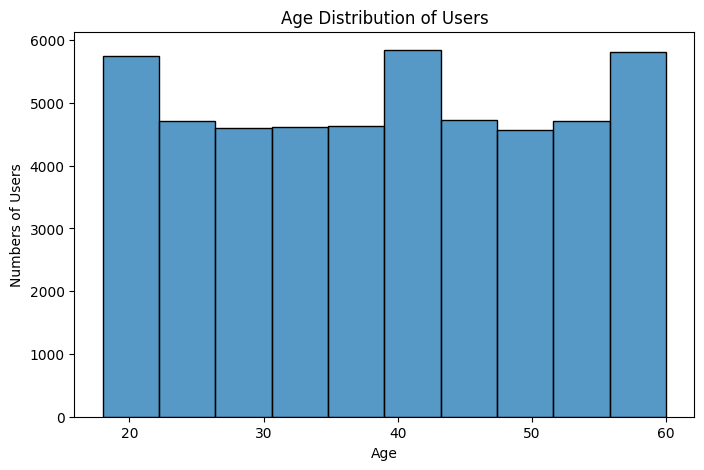

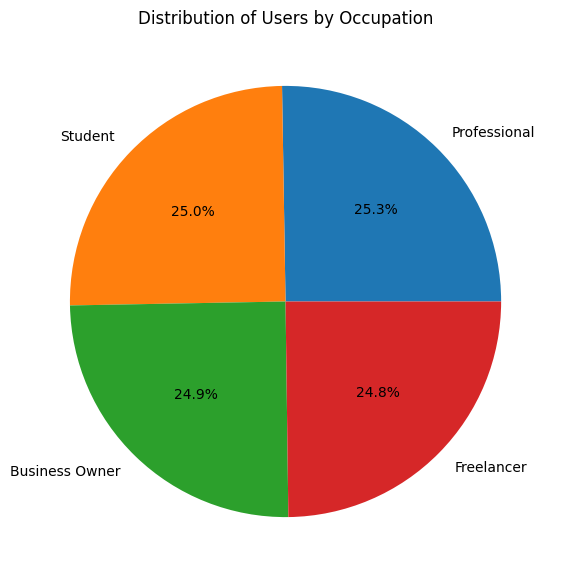

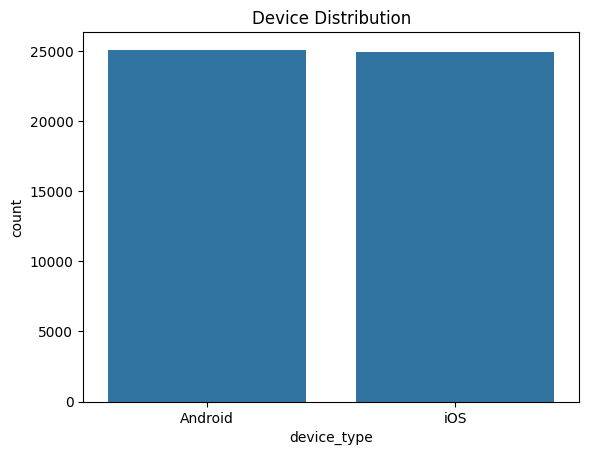

In [31]:
#age distribution
plt.figure(figsize = (8,5))

sns.histplot(
    df["age"],
    bins = 10
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Numbers of Users")
plt.show()

#users by occupation
occupation_counts = df["occupation"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    occupation_counts,
    labels = occupation_counts.index,
    autopct = "%1.1f%%",
    # startangle = 90
)
plt.title("Distribution of Users by Occupation")
plt.show()

#device distribution
sns.countplot(data = df, x = "device_type")
plt.title("Device Distribution")
plt.show()

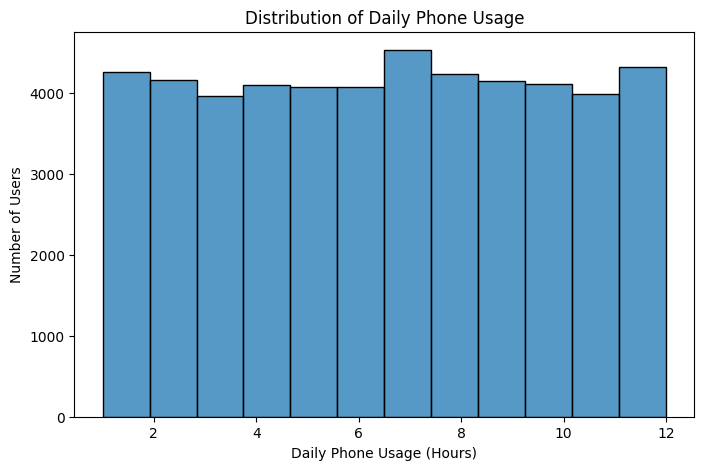

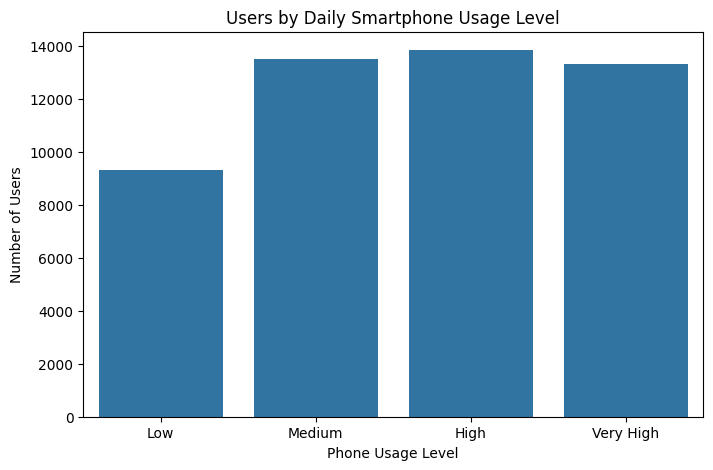

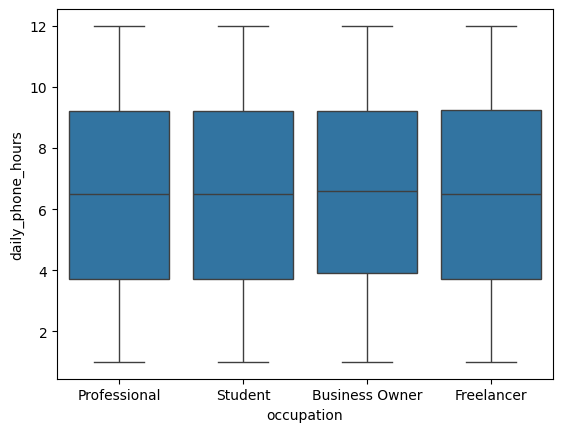

In [34]:
#daily phone usage distribution

plt.figure(figsize=(8,5))
sns.histplot(
    df["daily_phone_hours"],
    bins = 12,
)
plt.title("Distribution of Daily Phone Usage")
plt.xlabel("Daily Phone Usage (Hours)")
plt.ylabel("Number of Users")
plt.show()

#smartphone_usage_category
phone_usage_counts = df["phone_usage_category"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=phone_usage_counts.index,
    y=phone_usage_counts.values
)

plt.title("Users by Daily Smartphone Usage Level")
plt.xlabel("Phone Usage Level")
plt.ylabel("Number of Users")

plt.show()

#occupation wise
sns.boxplot(
    data=df,
    x="occupation",
    y="daily_phone_hours"
)
plt.show()

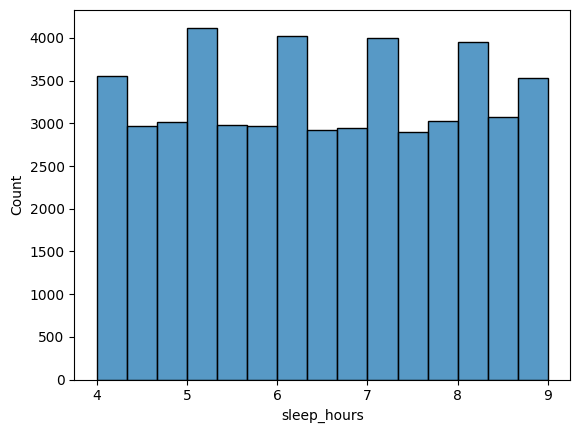

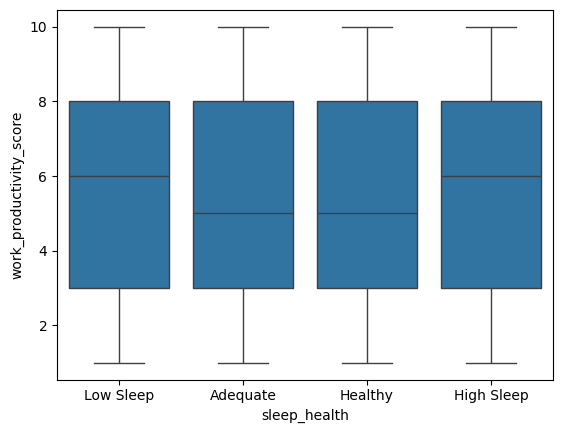

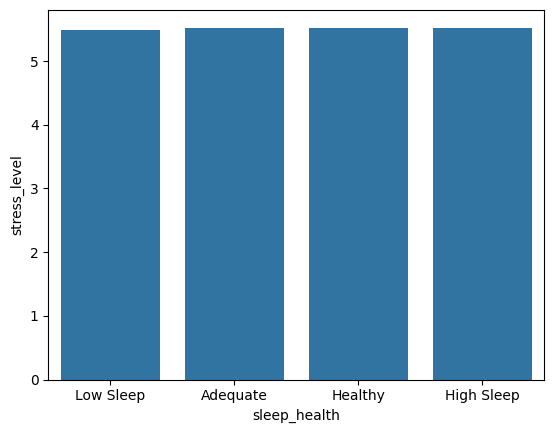

In [41]:
#sleep distribution
sns.histplot(
    data=df,
    x="sleep_hours",
    bins=15,
)
plt.show()

#sleep category vs productivity
sns.boxplot(
    data=df,
    x="sleep_health",
    y="work_productivity_score"
)
plt.show()

#sleep category vs stress
sleep_stress = (
    df.groupby("sleep_health", observed=True)["stress_level"]
      .mean()
      .reset_index()
)

sns.barplot(
    data=sleep_stress,
    x="sleep_health",
    y="stress_level"
)
plt.show()

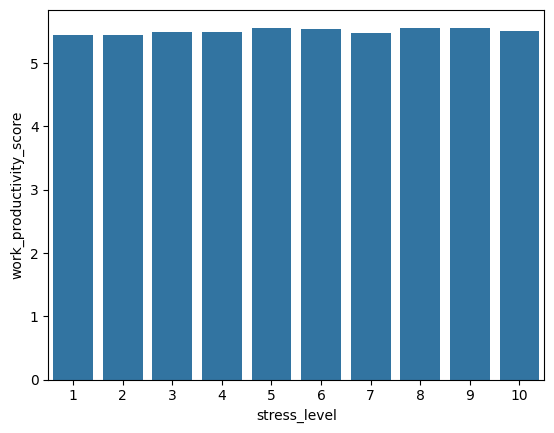

In [42]:
#productivity by stress level
stress_productivity = (
    df.groupby("stress_level")["work_productivity_score"]
      .mean()
      .reset_index()
)
sns.barplot(
    data=stress_productivity,
    x="stress_level",
    y="work_productivity_score"
)
plt.show()

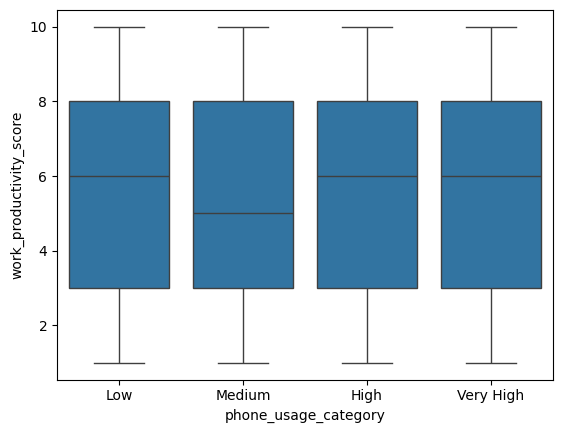

In [43]:
#smartphone usage level vs work productivity
sns.boxplot(
    data=df,
    x="phone_usage_category",
    y="work_productivity_score"
)
plt.show()

In [ ]:
#daily vs weekend screen time
weekend_usage = (
    df.groupby("occupation")[
        ["daily_phone_hours", "weekend_screen_time_hours"]
    ]
    .mean()
    .reset_index()
)

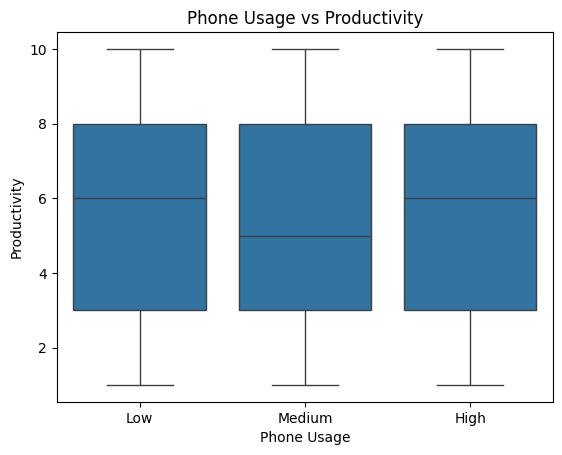

In [87]:
# data visualiztion

# Does higher smartphone usage reduce productivity?
sns.boxplot(x="phone_usage_category", y="work_productivity_score", data=df)
plt.title("Phone Usage vs Productivity")
plt.xlabel("Phone Usage")
plt.ylabel("Productivity")
plt.show()
# Medium phone users show the lowest typical productivity.
# Low and High users appear similar at the median level.
# This means there is no strong trend that high phone usage results in low productivity.
# So, there must be other factors in consideration like sleep, stress, occupation, etc.

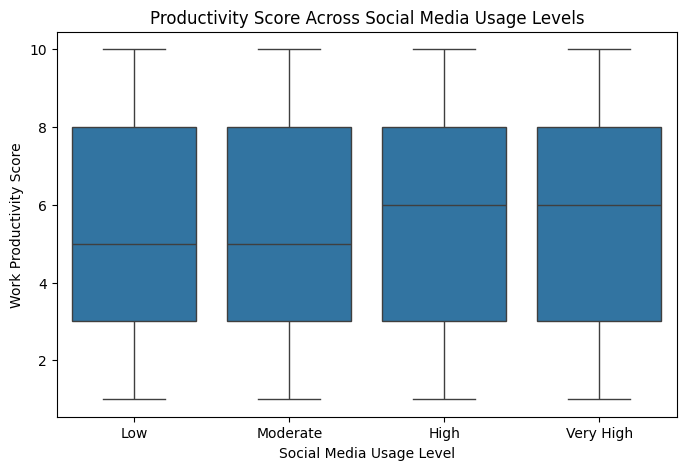

In [44]:
# social media usage vs productivity

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="social_media_category",
    y="work_productivity_score",
    data=df
)

plt.title("Productivity Score Across Social Media Usage Levels")
plt.xlabel("Social Media Usage Level")
plt.ylabel("Work Productivity Score")

plt.show()

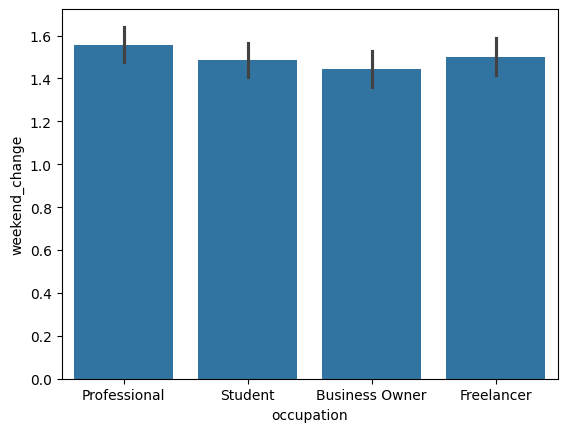

In [45]:
# weekend change by occupation
sns.barplot(
    data=df,
    x="occupation",
    y="weekend_change"
)
plt.show()

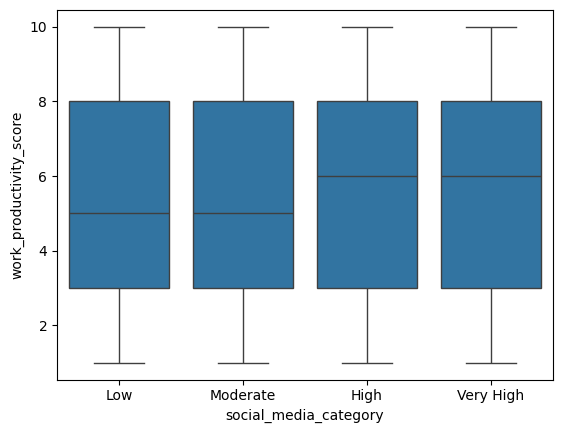

In [46]:
# social media usage category vs productivity
sns.boxplot(
    data=df,
    x="social_media_category",
    y="work_productivity_score"
)
plt.show()

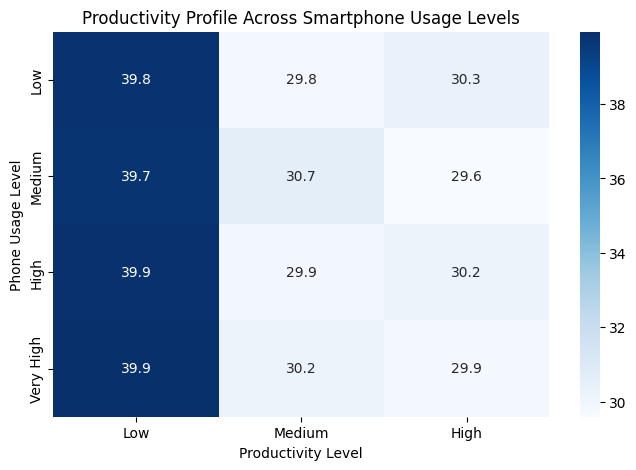

In [49]:
table = pd.crosstab(
    df["phone_usage_category"],
    df["productivity_level"],
    normalize="index"
) * 100

plt.figure(figsize=(8,5))

sns.heatmap(
    table,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Productivity Profile Across Smartphone Usage Levels")
plt.xlabel("Productivity Level")
plt.ylabel("Phone Usage Level")

plt.show()